In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('income.xlsx', names=["name", "age", "income"])
print(df.head())

      name  age  income
0      Rob   29      45
1   Andrea   50      80
2    Mohan   35      52
3  Michael   32      41
4     Kory   36      87


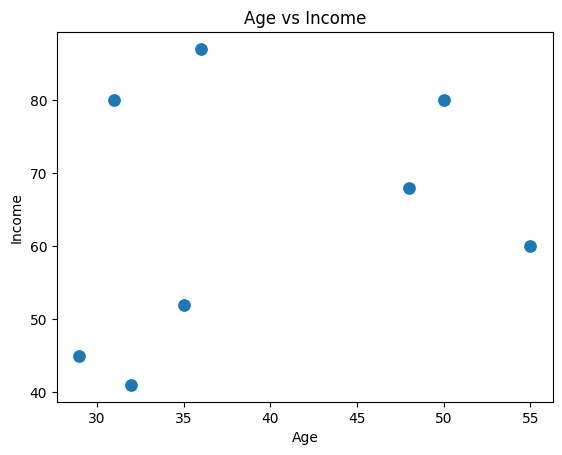

In [3]:
sns.scatterplot(x='age', y='income', data=df, s=100)
plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()


In [5]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler


clustering = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = clustering.fit(df[['age', 'income']])
df['cluster'] = labels.labels_
print(df.head())

      name  age  income  cluster
0      Rob   29      45        1
1   Andrea   50      80        0
2    Mohan   35      52        1
3  Michael   32      41        1
4     Kory   36      87        2


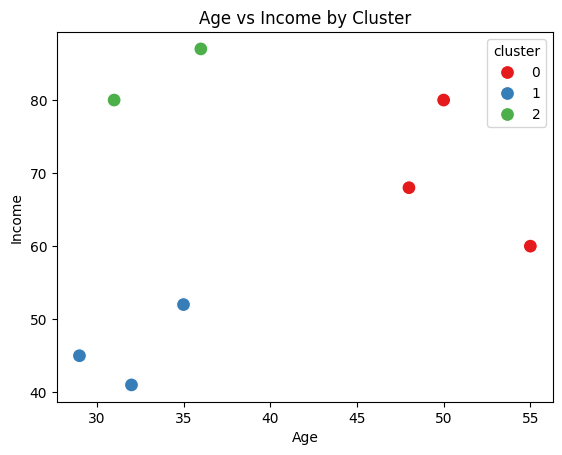

In [6]:
sns.scatterplot(x='age', y='income', data=df, hue='cluster', palette='Set1', s=100)
plt.title('Age vs Income by Cluster')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
X = df[['age', 'income']]
Z = linkage(X, method='average')

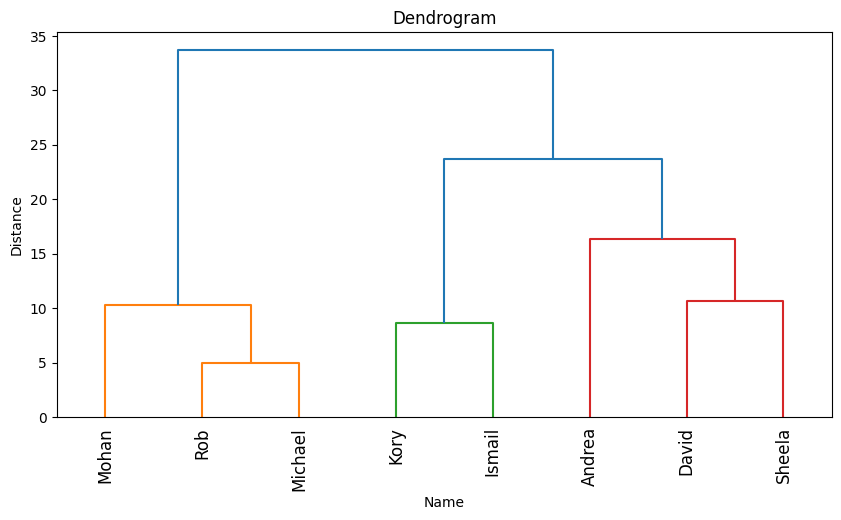

In [8]:
# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=df['name'].values, leaf_rotation=90)
plt.title('Dendrogram')
plt.xlabel('Name')
plt.ylabel('Distance')
plt.show()

In [9]:
fclusters = fcluster(Z, t=3, criterion='maxclust')
df['fcluster'] = fclusters

In [10]:
df.head()

,name,age,income,cluster,fcluster
0,Rob,29,45,1,1
1,Andrea,50,80,0,3
2,Mohan,35,52,1,1
3,Michael,32,41,1,1
4,Kory,36,87,2,2


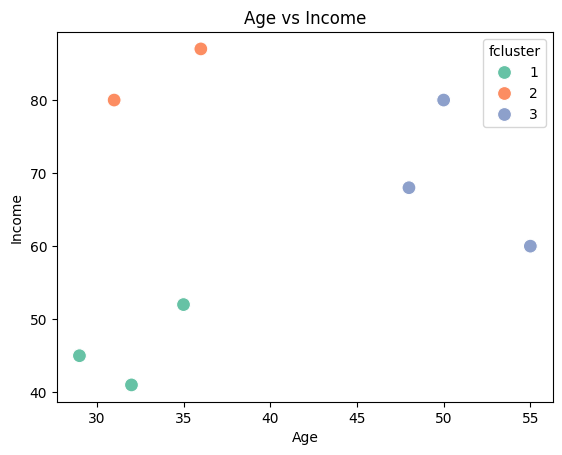

In [12]:
sns.scatterplot(x='age', y='income', data=df, hue='fcluster', palette='Set2', s=100)
plt.title('Age vs Income')  
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()